# 05 - Visualization and Insights

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/air_quality_cleaned.csv")
pm25 = df[df["pollutant_id"] == "PM2.5"]
pm10 = df[df["pollutant_id"] == "PM10"]
print("Data loaded.")

Data loaded.


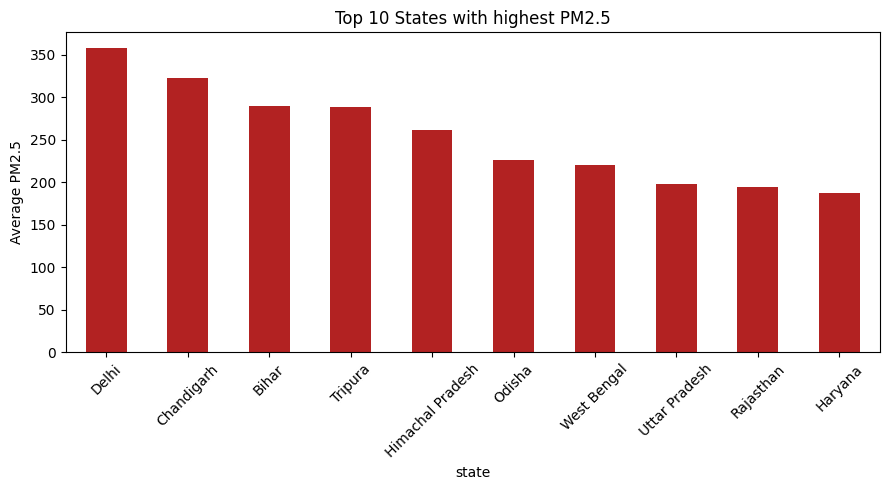

In [2]:
# top 10 states bar chart for PM2.5
top_states = pm25.groupby("state")["pollutant_avg"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(9, 5))
top_states.plot(kind="bar", color="firebrick")
plt.title("Top 10 States with highest PM2.5")
plt.ylabel("Average PM2.5")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../outputs/figures/05_top_states_pm25.png")
plt.show()

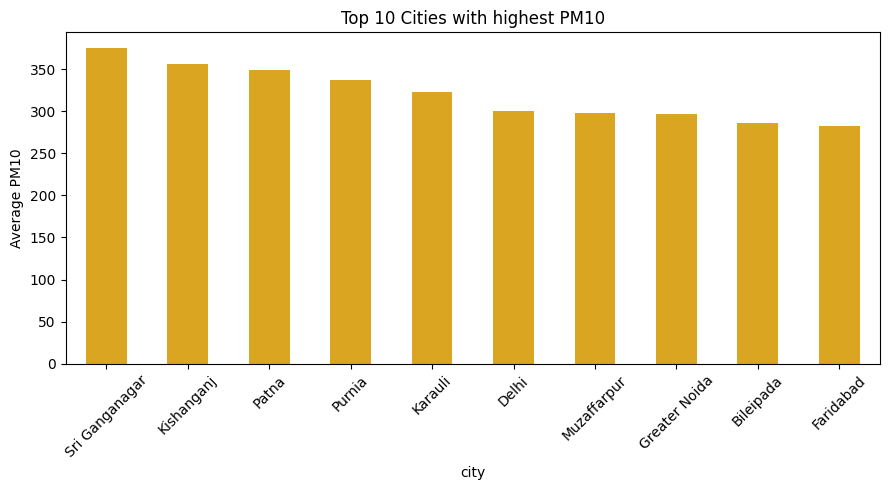

In [3]:
# top 10 cities bar chart for PM10
top_cities = pm10.groupby("city")["pollutant_avg"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(9, 5))
top_cities.plot(kind="bar", color="goldenrod")
plt.title("Top 10 Cities with highest PM10")
plt.ylabel("Average PM10")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../outputs/figures/06_top_cities_pm10.png")
plt.show()

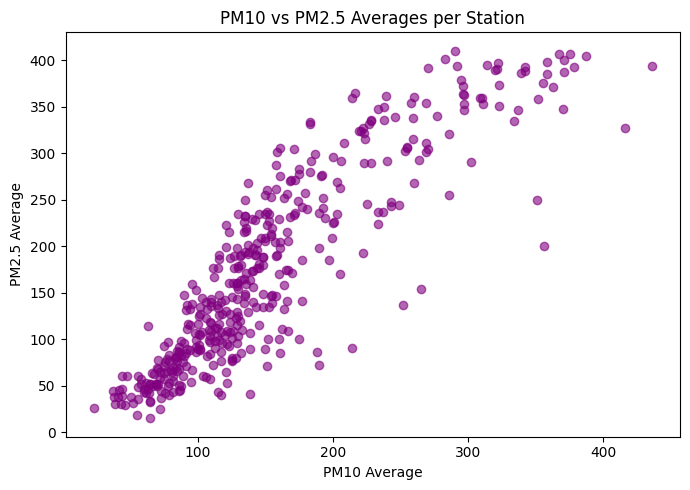

In [4]:
# scatter plot PM2.5 vs PM10
pm25_st = pm25.groupby("station")["pollutant_avg"].mean()
pm10_st = pm10.groupby("station")["pollutant_avg"].mean()

merged = pd.DataFrame({"PM2.5": pm25_st, "PM10": pm10_st}).dropna()

plt.figure(figsize=(7, 5))
plt.scatter(merged["PM10"], merged["PM2.5"], alpha=0.6, color="purple")
plt.title("PM10 vs PM2.5 Averages per Station")
plt.xlabel("PM10 Average")
plt.ylabel("PM2.5 Average")
plt.tight_layout()
plt.savefig("../outputs/figures/07_pm10_vs_pm25.png")
plt.show()

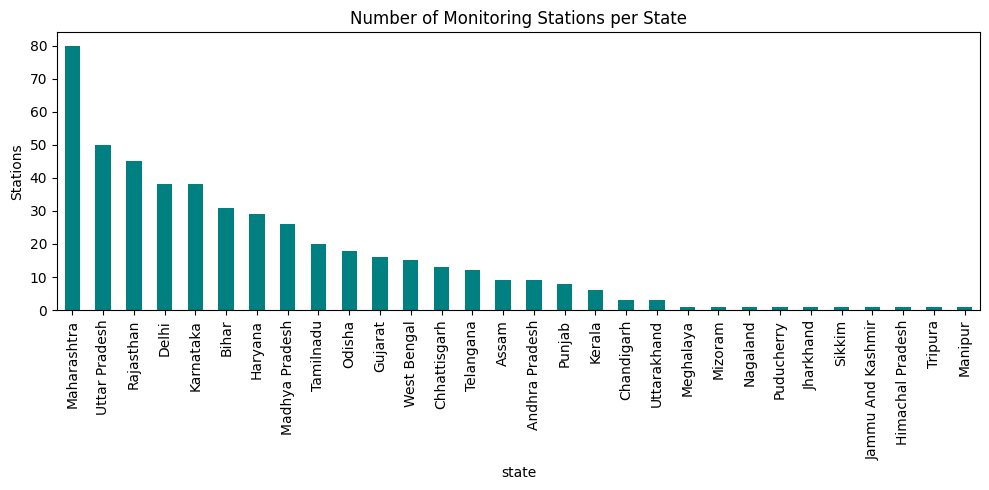

In [5]:
# number of stations per state
station_counts = df.groupby("state")["station"].nunique().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
station_counts.plot(kind="bar", color="teal")
plt.title("Number of Monitoring Stations per State")
plt.ylabel("Stations")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("../outputs/figures/08_stations_per_state.png")
plt.show()